# GNN — 1 Lepton 2 Taus (Run 2 / Run 3 / Combined)

Graph-neural-network counterpart to `DNN.ipynb`'s flat-feature MLP, on the
same 1l2tau data (`Evie/PPSSP_2026/1l2tau/{run2,run3}`), same preselection,
same leakage-free feature policy, and the same deterministic 80/10/10
train/val/test split — so results are directly comparable.

**Representation change.** The MLP concatenates every event into one flat
feature vector (kinematics + hand-engineered pairwise variables like `dR_*`,
`m_*`, `HT_*`). This notebook instead represents each event as a small graph:
one node per reconstructed physics object (lepton, tau1, tau2, jet1, jet2,
MET), each carrying only its own kinematics, with a fully-connected edge set
within the event. The hand-engineered pairwise/aggregate variables are
deliberately **not** given to the model — the point of the GNN is to see how
much of that relational information (angular separations, invariant masses,
combined momenta) message passing can recover on its own from raw 4-vectors.

**Scope.** This mirrors the core of the MLP pipeline — data loading, graph
construction, model, training with early stopping, ROC/AUC evaluation,
permutation-based feature importance and a single held-out test evaluation —
independently for **Run 2**, **Run 3** and a **Run 2 + Run 3 Combined** track
(same architecture and node schema shared across all three; only the
underlying data/statistics differ per track), mirroring `DNN.ipynb`'s
Run2/Run3/Combined section layout. Correlation pruning and hyperparameter
grid search are intentionally left out (they don't map as cleanly onto graph
nodes / a fixed small architecture) — see `DNN.ipynb` for those. A final
"Consolidated Summary" section compares all three tracks and exports a
standardized `model_summary_gnn.csv` for `ModelComparison.ipynb`.


## Libraries

In [52]:
import os

# Must be set BEFORE CUDA/cuBLAS initializes for deterministic cuBLAS matmul.
# If this kernel already has CUDA initialized (e.g. you've run cells before
# adding this), these two env vars won't take effect until you RESTART THE
# KERNEL.

os.environ["PYTHONHASHSEED"] = "42"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

# torch and uproot (via numpy) can each bundle their own OpenMP runtime;
# loading both in one process aborts the kernel on some platforms
# ("OMP: Error #15 ... libomp.dylib already initialized") unless this is
# set before either is imported.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

from torch_geometric.nn import GATv2Conv, global_mean_pool, global_max_pool

RANDOM_STATE = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed: int = RANDOM_STATE):

    """
    Full determinism, not just seeding: also pins cuDNN to deterministic
    kernels, disables its autotuner, and asks torch to error out (rather than
    silently fall back) on any op without a deterministic implementation.
    Same convention as DNN.ipynb's set_seed, so re-seeded runs here are
    reproducible the same way. Determinism is only guaranteed on the SAME
    machine / CUDA / torch version - it is not portable across hardware or
    library versions.
    """

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)


set_seed(RANDOM_STATE)

print(f"Using device: {DEVICE}")

Using device: cuda


In [53]:
# ---------------------------------------------------------------------------
# Paths - 1 lepton + 2 taus, Run 2 and Run 3 (same source files as DNN.ipynb /
# the Final_Notebooks/1L2Tau_Master_Pipeline.ipynb, so results are comparable).
# ---------------------------------------------------------------------------

BASE_DIR_RUN2 = Path("PPSSP_2026/1l2tau/run2")
BASE_DIR_RUN3 = Path("PPSSP_2026/1l2tau/run3")
BASE_DIR_COMB = Path("PPSSP_2026/1l2tau/combined")
BASE_DIR = BASE_DIR_RUN2
ACTIVE_RUN = "Run 2"
TREE_NAME = "AnalysisMiniTree"

# ---------------------------------------------------------------------------
# Preselection (see repo README.md, "1 Lepton 2 Taus")
# ---------------------------------------------------------------------------

PRESELECTION = "(n_b_jet == 0) & (n_jet >= 2)"

# ---------------------------------------------------------------------------
# Processes: filename + label (1 = signal, 0 = background)
# ---------------------------------------------------------------------------

FILES = {
    "signal_ggF": ("signal_ggF.root", 1),
    "signal_VBF": ("signal_VBF.root", 1),
    "Diboson":    ("diboson.root",    0),
    "Zjets":      ("Zjets.root",      0),
    "Wjets":      ("Wjets.root",      0),
    "ttbar":      ("ttbar.root",      0),
    "tops":       ("tops.root",       0),
    "SingleH":    ("singleH.root",    0),
    "Vgamma":     ("Vgamma.root",     0),
    "VVV":        ("VVV.root",        0),
}

WEIGHT_PARTS = ["weight", "weights"]  # raw branches; w_phys = their product

# ---------------------------------------------------------------------------
# Leakage-free feature-selection policy - IDENTICAL to DNN.ipynb / the
# XGBoost master pipeline, so this notebook builds graph nodes only out of
# branches the other models are also allowed to see.
# ---------------------------------------------------------------------------

BLOCK_SUBSTR = ["weight", "effsf", "_ff", "truth", "istrue", "fake", "anti",
                "dsid", "eventnumber", "_RNNTight", "_isOS", "_d0sig"]
BLOCK_EXACT = {
    "n_b_jet", "pass1l2tau", "hhml_subchannelflavor",
    "tau1_RNNJetScoreSigTrans", "tau2_RNNJetScoreSigTrans",
    "pair_isOStaus", "pair_isOSleptau", "tau2_baseline_RNNTight", "l1_d0sig", "tau1_charge", "tau2_charge", "mZ_veto", "tau1_decayMode", "tau2_decayMode", "tau1_nprong", "tau2_nprong"
}

BLOCK_EXACT_LOWER = {b.lower() for b in BLOCK_EXACT}


def is_feature(branch: str) -> bool:

    """True if `branch` is safe to use as a training feature (see policy above)."""

    lb = branch.lower()
    return lb not in BLOCK_EXACT_LOWER and not any(s.lower() in lb for s in BLOCK_SUBSTR)


## Data Loading Helpers

Identical to `DNN.ipynb`'s loaders - same discovery, same preselection, same
sentinel-to-NaN cleaning - so `data`/`features` here are byte-identical to
the MLP notebook's Run 2 `data_run2`/`features_run2`.

In [54]:
def discover_common_features(base_dir, files=FILES, tree_name=TREE_NAME):

    """
    Branches common to EVERY process file in `base_dir`, filtered through`is_feature`.
    """

    common = None

    for fname, _ in files.values():
        keys = set(uproot.open({str(Path(base_dir) / fname): tree_name}).keys())
        common = keys if common is None else common & keys

    features = sorted(b for b in common if is_feature(b))

    print(f"{len(features)} candidate features (common to all {len(files)} processes, leakage-free)")

    return features


def load_run_data(base_dir, features, files=FILES, weight_parts=WEIGHT_PARTS,
                   preselection=PRESELECTION, tree_name=TREE_NAME, verbose=True):

    """
    Read every process file under `base_dir`, apply the preselection at
    read time, and concatenate into one DataFrame with bookkeeping columns:
      - w_phys  : physical event weight = weight * weights
      - label   : 1 = signal, 0 = background
      - process : originating process name
    """

    base_dir = Path(base_dir)
    dfs = []

    for proc, (fname, label) in files.items():

        tree = uproot.open({str(base_dir / fname): tree_name})
        df = tree.arrays(features + weight_parts, cut=preselection, library="pd")
        df["w_phys"] =  df["weights"] * df["weight"]
        df["label"] = label
        df["process"] = proc
        dfs.append(df)

        if verbose:
            print(f"{proc:12s}: {len(df):>8d} events after preselection")

    return pd.concat(dfs, ignore_index=True)


def clean_data(data, features, verbose=True):

    """
    Post-concat cleaning: drop constant/empty features, then mask sentinel
    values (< -100, e.g. -999) to NaN. Returns (cleaned_data, updated_features);
    operates on a copy, does not mutate the input DataFrame.
    """

    data = data.copy()
    nun = data[features].nunique()
    const = nun[nun <= 1].index.tolist()
    features = [f for f in features if f not in const]
    data = data.drop(columns=const)

    if verbose:
        print(f"Dropped {len(const)} constant/empty features:\n  {sorted(const)}")

    for f in features:
        m = data[f] < -100
        if m.any():
            if verbose:
                print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
            data[f] = data[f].mask(m)

    if verbose:
        print(f"\n{len(features)} final features")
        print(f"Total: {len(data)} events | signal = {(data.label==1).sum()} | "
              f"background = {(data.label==0).sum()}")
        print(f"Yield (w_phys): signal = {data.loc[data.label==1,'w_phys'].sum():.2f} | "
              f"background = {data.loc[data.label==0,'w_phys'].sum():.2f}")
    return data, features

## Load Run 2 + Run 3 Data (Shared Setup)

Both campaigns are discovered/loaded/cleaned here (mirrors `DNN.ipynb`'s
shared-setup cell) so `data_run2`/`data_run3` are both ready before any
downstream section runs. The **Run 2** track below is the default active
dataset (`data`/`features` aliased to the Run 2 versions); the separate
**Run 3** and **Combined** sections further down explicitly switch/rebuild
`data`/`features` and use `_run3`/`_comb`-suffixed variables so nothing here
gets overwritten.


In [55]:
# Run 2 load

candidate_features_run2 = discover_common_features(BASE_DIR_RUN2)
data_run2 = load_run_data(BASE_DIR_RUN2, candidate_features_run2)
data_run2, features_run2 = clean_data(data_run2, candidate_features_run2)

# Run 3 load (prepared now; used later in a separate downstream section)

candidate_features_run3 = discover_common_features(BASE_DIR_RUN3)
data_run3 = load_run_data(BASE_DIR_RUN3, candidate_features_run3)
data_run3, features_run3 = clean_data(data_run3, candidate_features_run3)

# Default active dataset for downstream cells in this first pass: Run 2.

candidate_features, data, features = candidate_features_run2, data_run2, features_run2
BASE_DIR = BASE_DIR_RUN2
ACTIVE_RUN = "Run 2"

print(f"Prepared datasets: Run2={len(data_run2)} events, Run3={len(data_run3)} events")
print(f"Downstream now uses: {ACTIVE_RUN} | {len(features)} leakage-free features available")


81 candidate features (common to all 10 processes, leakage-free)
signal_ggF  :    67075 events after preselection
signal_VBF  :    21639 events after preselection
Diboson     :   312600 events after preselection
Zjets       :   141863 events after preselection
Wjets       :    31272 events after preselection
ttbar       :     7335 events after preselection
tops        :    62238 events after preselection
SingleH     :    11124 events after preselection
Vgamma      :    21510 events after preselection
VVV         :    14028 events after preselection
Dropped 17 constant/empty features:
  ['SumPt_l1j1j2', 'SumPt_t1t2l1', 'dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'm_jjl1', 'm_jjl1t1', 'm_jjt1', 'n_lep', 'n_tau', 'pass_DLT', 'tau1_base_id', 'tau1_besline_RNNMedium_eleid', 'tau1_passOR', 'tau2_base_id', 'tau2_besline_RNNMedium_eleid', 'tau2_passOR']

64 final features
Total: 690684 events | signal = 88714 | background = 601970
Yield (w_phys): signal = 1.82 | background = 11467.29
81 candidat

## Sentinel Audit (-1)

Same diagnostic as `DNN.ipynb`: `clean_data` only masks `< -100` sentinels
(e.g. `-999`) to NaN. Some ATLAS branches instead default to exactly `-1`
for "undefined", which is also a perfectly valid value for other branches
(e.g. charges) - so it must **not** be blanket-masked. Kept empty here to
match the MLP notebook's audited conclusion (no genuine `-1` sentinels among
the leakage-free features for this dataset); re-run and inspect
`neg1_df` if the upstream ntuples change.

In [56]:
NEG1_SENTINEL_FEATURES = set()

neg1_rows = []
for f in features:
    vals = data[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df = pd.DataFrame(neg1_rows).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df)} / {len(features)} features have at least one row exactly equal to -1:")
print(neg1_df.to_string(index=False))

for f in NEG1_SENTINEL_FEATURES:
    data[f] = data[f].mask(data[f] == -1)

if NEG1_SENTINEL_FEATURES:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES)}")
else:
    print("\nNEG1_SENTINEL_FEATURES is empty - no -1 values masked.")

1 / 64 features have at least one row exactly equal to -1:
  feature  frac_exactly_-1  gap_to_next_value_above
l1_charge         0.474042                      2.0

NEG1_SENTINEL_FEATURES is empty - no -1 values masked.


## Train/Validation/Test Split

Same deterministic two-stage stratified **80/10/10** split (`make_3way_split`)
as `DNN.ipynb`, on the same `data` - so TEST here is the same set of events as
the MLP notebook's TEST, cross-checked against its persisted partition.
TEST is held out from everything below (imputation, scaling, early stopping)
until the single "Held-Out Test Evaluation" cell at the end.

In [57]:
def make_fit_weights(labels, abs_weights):

    """
    Balance signal/background total weight and normalize the mean weight
    to 1. `abs_weights` must already be non-negative (Sherpa weights can be
    negative).
    """

    labels = np.asarray(labels)

    fit_weights = np.asarray(abs_weights, dtype=float).copy()
    sum_signal = fit_weights[labels == 1].sum()
    sum_background = fit_weights[labels == 0].sum()
    fit_weights[labels == 1] *= sum_background / sum_signal
    fit_weights *= len(fit_weights) / fit_weights.sum()

    return fit_weights


def make_3way_split(data, test_size=0.10, val_size=0.10, seed=RANDOM_STATE, extra_stratify_col=None):

    """
    Deterministic two-stage stratified 80/10/10 train/val/test split -
    IDENTICAL logic (same seed, same stratify) to DNN.ipynb's
    make_3way_split, so both notebooks land on the same partitions whenever
    `data` is built identically (same FILES order -> concat -> clean_data).
    """

    def _strata(df):
        if extra_stratify_col is not None:
            return df["label"].astype(str) + "_" + df[extra_stratify_col].astype(str)
        return df["label"]

    trainval_df, test_df = train_test_split(data, test_size=test_size, random_state=seed, stratify=_strata(data))

    val_frac_of_remaining = val_size / (1 - test_size)
    train_df, val_df = train_test_split(
        trainval_df, test_size=val_frac_of_remaining, random_state=seed, stratify=_strata(trainval_df)
    )

    for name, df in (("Train", train_df), ("Val", val_df), ("Test", test_df)):
        sig_n, bkg_n = int((df.label == 1).sum()), int((df.label == 0).sum())
        sig_y = df.loc[df.label == 1, "w_phys"].sum()
        bkg_y = df.loc[df.label == 0, "w_phys"].sum()
        print(f"{name:5s}: {len(df):>8d} events | signal = {sig_n:>7d} (yield={sig_y:>10.2f}) | "
              f"background = {bkg_n:>7d} (yield={bkg_y:>10.2f}) | "
              f"signal weight scale factor = {bkg_y / sig_y:.1f}")

    return train_df, val_df, test_df


def assert_same_test_partition(test_df, path):

    """
    Cross-notebook guard: if a test partition already exists on disk at
    `path` (written by DNN.ipynb / the master pipeline reading this same
    BASE_DIR), verify this notebook's freshly-computed `test_df` is
    equal to it on their shared columns.
    """

    path = Path(path)
    if not path.exists():
        print(f"  (no prior test partition at {path} yet - nothing to cross-check)")
        return

    prior_df = uproot.open({str(path): "tree"}).arrays(library="pd")
    cols = sorted((set(test_df.columns) & set(prior_df.columns)) - {"run"})
    a = test_df[cols].sort_values(cols).reset_index(drop=True)
    b = prior_df[cols].sort_values(cols).reset_index(drop=True)

    pd.testing.assert_frame_equal(a, b, check_exact=False, rtol=1e-5, atol=1e-8, check_dtype=False)
    print(f"  cross-check OK: {path} test partition matches on {len(cols)} shared columns ({len(test_df)} rows)")


train_df, val_df, test_df = make_3way_split(data)

SPLIT_DIR_RUN2 = BASE_DIR_RUN2 / "splits"
assert_same_test_partition(test_df, SPLIT_DIR_RUN2 / "test.root")

Train:   552546 events | signal =   70971 (yield=      1.46) | background =  481575 (yield=   9202.46) | signal weight scale factor = 6316.7
Val  :    69069 events | signal =    8872 (yield=      0.18) | background =   60197 (yield=   1129.19) | signal weight scale factor = 6142.7
Test :    69069 events | signal =    8871 (yield=      0.18) | background =   60198 (yield=   1135.64) | signal weight scale factor = 6181.7
  cross-check OK: PPSSP_2026/1l2tau/run2/splits/test.root test partition matches on 69 shared columns (69069 rows)


## Object / Node Schema

Six nodes per event, one per reconstructed object, using only branches that
survive the leakage-free `is_feature` policy above and that `clean_data`
didn't drop as constant (checked against this dataset: the tau `_base_id` /
`_passOR` / `_besline_RNNMedium_eleid` flags are constant post-preselection
and so aren't available - only kinematics remain for tau1/tau2).

| node   | source prefix | fields                          |
|--------|---------------|----------------------------------|
| lepton | `l1_`         | pt, eta, phi, e, charge, pdg (-> is_electron) |
| tau1   | `tau1_`       | pt, eta, phi                     |
| tau2   | `tau2_`       | pt, eta, phi                     |
| jet1   | `j1_`         | pt, eta, phi, e                  |
| jet2   | `j2_`         | pt, eta, phi, e                  |
| MET    | `met_`        | met (-> pt slot), phi, sumet (-> e slot) |

Each node's feature vector is `[pt, eta, sin(phi), cos(phi), e, charge,
is_electron, is_lepton, is_tau, is_jet, is_met]` (11 dims) - fields that
don't apply to an object (e.g. tau charge, blocked as leakage; MET eta,
undefined) are zero-filled, and the 4-way type one-hot lets the (shared)
graph-conv weights tell object roles apart. `phi` is encoded as
`(sin, cos)` rather than a raw scaled scalar so its circular topology
(`-pi` and `+pi` are the same angle) isn't broken by standard scaling.

In [58]:
OBJECT_COLUMNS = {
    "lepton": {"pt": "l1_pt",   "eta": "l1_eta",   "phi": "l1_phi",   "e": "l1_e", "charge": "l1_charge", "pdg": "l1_pdg"},
    "tau1":   {"pt": "tau1_pt", "eta": "tau1_eta", "phi": "tau1_phi"},
    "tau2":   {"pt": "tau2_pt", "eta": "tau2_eta", "phi": "tau2_phi"},
    "jet1":   {"pt": "j1_pt",   "eta": "j1_eta",   "phi": "j1_phi",   "e": "j1_e"},
    "jet2":   {"pt": "j2_pt",   "eta": "j2_eta",   "phi": "j2_phi",   "e": "j2_e"},
    "met":    {"pt": "met_met", "phi": "met_phi",  "e": "met_sumet"},
}
NODE_ORDER = ["lepton", "tau1", "tau2", "jet1", "jet2", "met"]
NODE_TYPE = {"lepton": "lepton", "tau1": "tau", "tau2": "tau", "jet1": "jet", "jet2": "jet", "met": "met"}
TYPE_LIST = ["lepton", "tau", "jet", "met"]
N_NODES = len(NODE_ORDER)
N_NODE_FEATURES = 7 + len(TYPE_LIST)  # pt, eta, sin(phi), cos(phi), e, charge, is_electron + type one-hot

REQUIRED_OBJECT_COLUMNS = sorted({c for cols in OBJECT_COLUMNS.values() for c in cols.values()})
missing = [c for c in REQUIRED_OBJECT_COLUMNS if c not in features]
assert not missing, f"Node schema references columns dropped by clean_data / the leakage policy: {missing}"

# Continuous columns (imputed + standard-scaled, fit on TRAIN only). phi is
# handled separately via sin/cos; charge and pdg-derived is_electron are
# left unscaled (0/1-ish flags - scaling would just relabel them).
CONTINUOUS_NODE_COLS = sorted({
    c for cols in OBJECT_COLUMNS.values() for k, c in cols.items() if k in ("pt", "eta", "e")
})

print(f"{N_NODES} nodes/event x {N_NODE_FEATURES} features/node")
print(f"{len(CONTINUOUS_NODE_COLS)} continuous columns to impute + scale: {CONTINUOUS_NODE_COLS}")

# Fully-connected edge set - identical topology for every event (n_jet >= 2
# in the preselection guarantees all 6 slots are always populated), so it's
# built once and shared across every graph.
EDGE_INDEX = torch.tensor(
    [[i, j] for i in range(N_NODES) for j in range(N_NODES) if i != j],
    dtype=torch.long,
).t().contiguous().to(DEVICE)

# ---- Batched edge_index / batch-vector helpers -----------------------------
# Every event shares the EXACT SAME graph topology, so a whole batch's
# disjoint-union edge_index and node->graph `batch` vector can be built with
# plain vectorized tensor ops (broadcasting/repeat), never a Python loop over
# individual graphs - this is what lets training skip PyG's DataLoader
# collation entirely (see the dataset-building / run_epoch cells below).
# Cached per batch size since the same size is reused every batch/epoch.
_edge_index_cache = {}
_batch_vector_cache = {}


def get_batched_edge_index(batch_size):

    """Disjoint-union `edge_index` for `batch_size` copies of EDGE_INDEX,
    node indices offset by i * N_NODES per graph i."""

    if batch_size not in _edge_index_cache:
        offsets = torch.arange(batch_size, device=DEVICE).repeat_interleave(EDGE_INDEX.shape[1]) * N_NODES
        _edge_index_cache[batch_size] = EDGE_INDEX.repeat(1, batch_size) + offsets
    return _edge_index_cache[batch_size]


def get_batch_vector(batch_size):

    """`batch` vector (which graph each of the batch_size * N_NODES rows of
    a flattened node tensor belongs to), matching PyG's `Batch.batch` convention."""

    if batch_size not in _batch_vector_cache:
        _batch_vector_cache[batch_size] = torch.arange(batch_size, device=DEVICE).repeat_interleave(N_NODES)
    return _batch_vector_cache[batch_size]


# ---- Median imputation (fit on TRAIN only), then standard scaling on the
# continuous columns only (fit on TRAIN only). Mirrors DNN.ipynb's
# imputation/scaling convention, restricted to the columns the graph nodes
# actually use.
train_medians = train_df[REQUIRED_OBJECT_COLUMNS].median()

train_imp = train_df[REQUIRED_OBJECT_COLUMNS].fillna(train_medians)
val_imp = val_df[REQUIRED_OBJECT_COLUMNS].fillna(train_medians)
test_imp = test_df[REQUIRED_OBJECT_COLUMNS].fillna(train_medians)

scaler = StandardScaler()
train_scaled = train_imp.copy()
val_scaled = val_imp.copy()
test_scaled = test_imp.copy()
train_scaled[CONTINUOUS_NODE_COLS] = scaler.fit_transform(train_imp[CONTINUOUS_NODE_COLS])
val_scaled[CONTINUOUS_NODE_COLS] = scaler.transform(val_imp[CONTINUOUS_NODE_COLS])
test_scaled[CONTINUOUS_NODE_COLS] = scaler.transform(test_imp[CONTINUOUS_NODE_COLS])

assert np.isfinite(train_scaled.to_numpy()).all(), "NaN/inf reached the model input (train)"
assert np.isfinite(val_scaled.to_numpy()).all(), "NaN/inf reached the model input (val)"
assert np.isfinite(test_scaled.to_numpy()).all(), "NaN/inf reached the model input (test)"

print("Imputation + scaling done (fit on train only).")

6 nodes/event x 11 features/node
15 continuous columns to impute + scale: ['j1_e', 'j1_eta', 'j1_pt', 'j2_e', 'j2_eta', 'j2_pt', 'l1_e', 'l1_eta', 'l1_pt', 'met_met', 'met_sumet', 'tau1_eta', 'tau1_pt', 'tau2_eta', 'tau2_pt']
Imputation + scaling done (fit on train only).


## Graph Construction

Vectorized build of the `(n_events, N_NODES, N_NODE_FEATURES)` node-feature
tensor for each split, then wrapped one `torch_geometric.data.Data` object
per event (all sharing the same precomputed `EDGE_INDEX`).

In [59]:
def stack_node_features(df_scaled, df_imp):

    """
    Vectorized construction of the (n_events, N_NODES, N_NODE_FEATURES) node
    tensor. `df_scaled` supplies pt/eta/e (imputed + standard-scaled);
    `df_imp` supplies phi/charge/pdg (imputed but NOT scaled - phi goes
    through sin/cos, charge/pdg are categorical-ish and left raw).
    """

    n = len(df_scaled)
    node_arrays = []

    for name in NODE_ORDER:
        cols = OBJECT_COLUMNS[name]

        pt = df_scaled[cols["pt"]].to_numpy(dtype=np.float32)
        eta = df_scaled[cols["eta"]].to_numpy(dtype=np.float32) if "eta" in cols else np.zeros(n, dtype=np.float32)
        phi = df_imp[cols["phi"]].to_numpy(dtype=np.float32)
        e = df_scaled[cols["e"]].to_numpy(dtype=np.float32) if "e" in cols else np.zeros(n, dtype=np.float32)
        charge = df_imp[cols["charge"]].to_numpy(dtype=np.float32) if "charge" in cols else np.zeros(n, dtype=np.float32)
        is_electron = (
            (np.abs(df_imp[cols["pdg"]].to_numpy()) == 11).astype(np.float32)
            if "pdg" in cols else np.zeros(n, dtype=np.float32)
        )
        type_onehot = np.tile(
            np.array([float(NODE_TYPE[name] == t) for t in TYPE_LIST], dtype=np.float32), (n, 1)
        )

        node_arrays.append(np.column_stack(
            [pt, eta, np.sin(phi), np.cos(phi), e, charge, is_electron, type_onehot]
        ))

    return np.stack(node_arrays, axis=1)  # (n, N_NODES, N_NODE_FEATURES)


def build_graph_tensors(df_scaled, df_imp, df_raw, fit_weights=None):

    """
    Vectorized construction of GPU-resident tensors for one split: `x`
    (n_events, N_NODES, N_NODE_FEATURES), `y` (n_events,), `w_fit` (training
    weights, or None), and `w_abs` (plain |w_phys|, always). Replaces the
    old per-event list-of-`Data`-objects + PyG `DataLoader` approach: since
    every event shares the EXACT SAME graph topology (`EDGE_INDEX`/`N_NODES`
    are fixed), there's no need for PyG's dynamic-graph collation machinery
    at all - that per-batch Python-level `Batch.from_data_list` loop was the
    actual training bottleneck, not model compute. If `fit_weights` is given
    (class-balanced + mean-normalized training weights), `w_fit` holds those
    (paired with `w_abs` for eval-mode metrics on the same split); otherwise
    `w_fit` is None and only `w_abs` is meaningful (the val/test convention).
    """

    x = torch.from_numpy(stack_node_features(df_scaled, df_imp)).to(DEVICE)
    y = torch.from_numpy(df_raw["label"].to_numpy(dtype=np.float32)).to(DEVICE)
    w_abs = torch.from_numpy(np.abs(df_raw["w_phys"].to_numpy(dtype=np.float32))).to(DEVICE)
    w_fit = torch.from_numpy(fit_weights.astype(np.float32)).to(DEVICE) if fit_weights is not None else None

    return x, y, w_fit, w_abs


w_train_fit = make_fit_weights(train_df["label"].to_numpy(), np.abs(train_df["w_phys"].to_numpy()))

X_train, y_train, w_train_fit_t, w_train_eval_t = build_graph_tensors(train_scaled, train_imp, train_df, fit_weights=w_train_fit)
X_val, y_val_labels, _, w_val_abs = build_graph_tensors(val_scaled, val_imp, val_df)
X_test, y_test_labels, _, w_test_abs_t = build_graph_tensors(test_scaled, test_imp, test_df)

print(f"Built {X_train.shape[0]} train / {X_val.shape[0]} val / {X_test.shape[0]} test graphs (GPU-resident tensors)")
print(f"Node tensor shape per split: (n_events, {N_NODES}, {N_NODE_FEATURES})")

Built 552546 train / 69069 val / 69069 test graphs (GPU-resident tensors)
Node tensor shape per split: (n_events, 6, 11)


## GNN Model

Two `GATv2Conv` message-passing layers (attention over the fully-connected
neighborhood learns which object pairs matter per event, the relational
analogue of the MLP's hand-picked `dR_*`/`m_*` features), then
mean+max graph-level pooling, then a small MLP head - same dropout +
single-logit-output convention as `DNN.ipynb`'s `SimpleMLP`.

In [60]:
BATCH_SIZE = 8192
DEFAULT_HIDDEN_CHANNELS = 64
DEFAULT_DROPOUT = 0.3


class ObjectGNN(nn.Module):

    """
    Object-level graph classifier: 2x GATv2Conv, mean+max pooling, MLP head,
    single output logit (paired with BCEWithLogitsLoss for numerical
    stability, same convention as DNN.ipynb's SimpleMLP).
    """

    def __init__(self, in_channels, hidden_channels=DEFAULT_HIDDEN_CHANNELS, dropout=DEFAULT_DROPOUT):

        super().__init__()
        self.conv1 = GATv2Conv(in_channels, hidden_channels)
        self.conv2 = GATv2Conv(hidden_channels, hidden_channels)
        self.dropout = dropout
        self.head = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_channels, hidden_channels // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1),
        )

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        return self.head(x).squeeze(-1)


def build_model(hidden_channels=DEFAULT_HIDDEN_CHANNELS, dropout=DEFAULT_DROPOUT, in_channels=None):

    """Factory so training/hyperparameter code can build a fresh model per trial."""

    if in_channels is None:
        in_channels = N_NODE_FEATURES
    return ObjectGNN(in_channels=in_channels, hidden_channels=hidden_channels, dropout=dropout).to(DEVICE)


model = build_model()
print(model)

ObjectGNN(
  (conv1): GATv2Conv(11, 64, heads=1)
  (conv2): GATv2Conv(64, 64, heads=1)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Training Loop

Weighted binary cross-entropy, Adam optimizer, early stopping on weighted
validation AUC - same convention as `DNN.ipynb`'s `train_model`. Every epoch
also runs an eval-mode pass over the training graphs (dropout off, plain
`|w_phys|` weights via `w_eval`) so the logged `train_auc_eval`/`val_auc`
pair is directly comparable (the dropout-on `train_auc` used for the
gradient step is not).

In [61]:
N_EPOCHS = 50
PATIENCE = 10
LEARNING_RATE = 1e-3


def run_epoch(model, X, y, w, criterion, optimizer, train, batch_size=BATCH_SIZE):

    """
    One pass over (X, y, w) in `batch_size`-sized chunks, optionally taking
    a gradient step. Batches via GPU-side tensor indexing (`torch.randperm`
    for shuffling on the train pass) instead of a PyG `DataLoader`, and the
    batched `edge_index`/`batch` vector come from the cached
    `get_batched_edge_index`/`get_batch_vector` helpers (vectorized, no
    per-graph Python loop). Only syncs to CPU ONCE at the end of the whole
    epoch (`.cpu().numpy()` below), not per batch - avoids both the CPU-bound
    per-batch graph collation AND the CUDA-sync overhead of the old
    DataLoader-based loop (each `.item()`/`.cpu()` call forces a full sync).
    """

    model.train(train)
    n = X.shape[0]
    order = torch.randperm(n, device=DEVICE) if train else torch.arange(n, device=DEVICE)

    total_loss = torch.zeros((), device=DEVICE)
    total_weight = torch.zeros((), device=DEVICE)
    all_labels, all_probs, all_weights = [], [], []

    with torch.set_grad_enabled(train):
        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            b = idx.shape[0]

            bx = X[idx].reshape(b * N_NODES, N_NODE_FEATURES)
            by = y[idx]
            bw = w[idx]

            logits = model(bx, get_batched_edge_index(b), get_batch_vector(b))
            loss = (criterion(logits, by) * bw).sum() / bw.sum()

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            bw_sum = bw.sum().detach()
            total_loss += loss.detach() * bw_sum
            total_weight += bw_sum
            all_labels.append(by.detach())
            all_probs.append(torch.sigmoid(logits).detach())
            all_weights.append(bw.detach())

    labels = torch.cat(all_labels).cpu().numpy()
    probs = torch.cat(all_probs).cpu().numpy()
    weights = torch.cat(all_weights).cpu().numpy()
    auc = roc_auc_score(labels, probs, sample_weight=weights)

    return (total_loss / total_weight).item(), auc


def score_dataset(model, X, batch_size=BATCH_SIZE):

    """
    Batched inference over `X` (n_events, N_NODES, N_NODE_FEATURES),
    returning sigmoid probabilities as a 1-D GPU tensor. Reused by the
    val/test evaluation cells below instead of a PyG DataLoader loop.
    """

    model.eval()
    all_p = []
    with torch.no_grad():
        for start in range(0, X.shape[0], batch_size):
            bx = X[start:start + batch_size]
            b = bx.shape[0]
            logits = model(bx.reshape(b * N_NODES, N_NODE_FEATURES), get_batched_edge_index(b), get_batch_vector(b))
            all_p.append(torch.sigmoid(logits))
    return torch.cat(all_p)


def train_model(hidden_channels=DEFAULT_HIDDEN_CHANNELS, dropout=DEFAULT_DROPOUT, lr=LEARNING_RATE,
                 n_epochs=N_EPOCHS, patience=PATIENCE, verbose=True,
                 X_train_data=None, y_train_data=None, w_train_fit_data=None, w_train_eval_data=None,
                 X_val_data=None, y_val_data=None, w_val_data=None):

    """
    Build a fresh ObjectGNN and train it with early stopping on weighted
    validation AUC. Returns (model, history, best_val_auc, best_train_auc,
    best_train_auc_eval) - `model` already has the best-epoch weights
    loaded, and the two train_auc numbers are read off that SAME epoch.
    """

    X_train_data = X_train if X_train_data is None else X_train_data
    y_train_data = y_train if y_train_data is None else y_train_data
    w_train_fit_data = w_train_fit_t if w_train_fit_data is None else w_train_fit_data
    w_train_eval_data = w_train_eval_t if w_train_eval_data is None else w_train_eval_data
    X_val_data = X_val if X_val_data is None else X_val_data
    y_val_data = y_val_labels if y_val_data is None else y_val_data
    w_val_data = w_val_abs if w_val_data is None else w_val_data

    trial_model = build_model(hidden_channels=hidden_channels, dropout=dropout)
    criterion = nn.BCEWithLogitsLoss(reduction="none")
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": [],
               "train_loss_eval": [], "train_auc_eval": []}
    best_val_auc, best_train_auc, best_train_auc_eval = -np.inf, None, None
    best_state, epochs_no_improve = None, 0

    for epoch in range(1, n_epochs + 1):

        train_loss, train_auc = run_epoch(trial_model, X_train_data, y_train_data, w_train_fit_data, criterion, optimizer, train=True)
        train_loss_eval, train_auc_eval = run_epoch(trial_model, X_train_data, y_train_data, w_train_eval_data, criterion, optimizer, train=False)
        val_loss, val_auc = run_epoch(trial_model, X_val_data, y_val_data, w_val_data, criterion, optimizer, train=False)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_auc"].append(train_auc)
        history["val_auc"].append(val_auc)
        history["train_loss_eval"].append(train_loss_eval)
        history["train_auc_eval"].append(train_auc_eval)

        if verbose:
            print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
                  f"| train_auc={train_auc:.4f} train_auc_eval={train_auc_eval:.4f} val_auc={val_auc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc, best_train_auc, best_train_auc_eval = val_auc, train_auc, train_auc_eval
            best_state, epochs_no_improve = {k: v.clone() for k, v in trial_model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val_auc={best_val_auc:.4f})")
                break

    trial_model.load_state_dict(best_state)
    return trial_model, history, best_val_auc, best_train_auc, best_train_auc_eval

In [62]:
model, history, best_val_auc, best_train_auc, best_train_auc_eval = train_model()

print(f"\nBest val_auc = {best_val_auc:.4f} | train_auc (dropout on) = {best_train_auc:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval:.4f}")

/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch   1 | train_loss=0.5768 val_loss=0.4067 | train_auc=0.7946 train_auc_eval=0.8704 val_auc=0.8685


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch   2 | train_loss=0.4661 val_loss=0.4836 | train_auc=0.8597 train_auc_eval=0.8760 val_auc=0.8742


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


...

Epoch  48 | train_loss=0.3846 val_loss=0.3731 | train_auc=0.9084 train_auc_eval=0.9148 val_auc=0.9091


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch  49 | train_loss=0.3830 val_loss=0.4291 | train_auc=0.9091 train_auc_eval=0.9154 val_auc=0.9093


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch  50 | train_loss=0.3830 val_loss=0.3980 | train_auc=0.9092 train_auc_eval=0.9159 val_auc=0.9100

Best val_auc = 0.9100 | train_auc (dropout on) = 0.9092 | train_auc_eval (dropout off, comparable) = 0.9159


## Evaluation

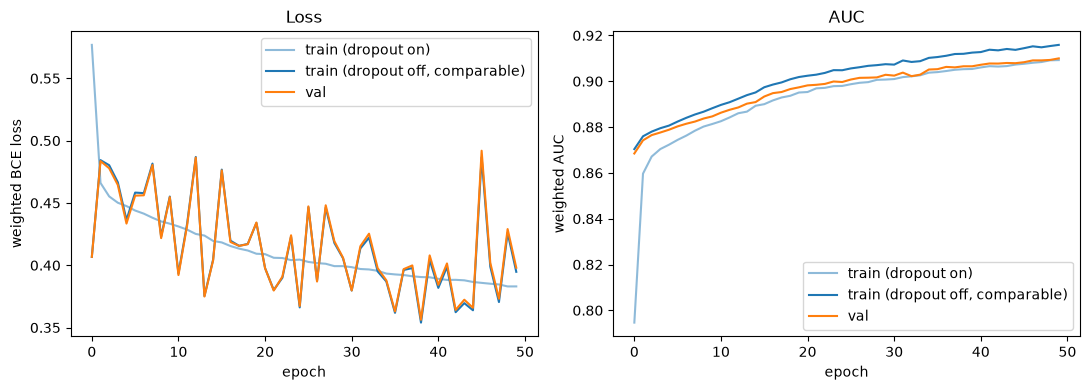

Final weighted val AUC = 0.9100


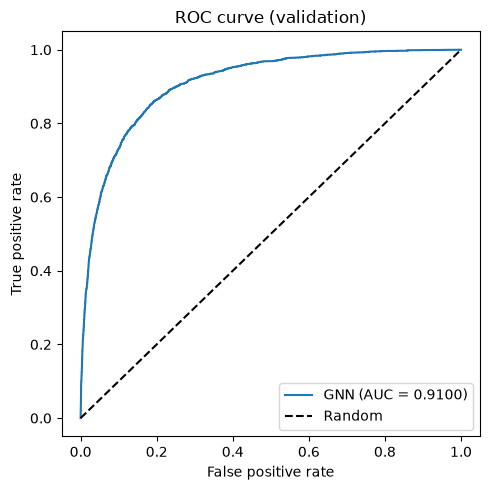

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

y_val_scores = score_dataset(model, X_val).cpu().numpy()
y_val = y_val_labels.cpu().numpy()
w_val = w_val_abs.cpu().numpy()

auc_val = roc_auc_score(y_val, y_val_scores, sample_weight=w_val)
print(f"Final weighted val AUC = {auc_val:.4f}")

fpr, tpr, _ = roc_curve(y_val, y_val_scores, sample_weight=w_val)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"GNN (AUC = {auc_val:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation)")
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance (Permutation)

Adapted to what the GNN actually sees, not a copy-paste of `DNN.ipynb`'s
version. `DNN.ipynb` ranks ~80 flat features, about 50 of which are
hand-engineered pairwise/aggregate variables (`dR_*`, `m_*`, `HT_*`) that
this notebook deliberately does **not** give the model - the whole point of
the graph representation is that message passing has to reconstruct that
relational information itself. So there are only the ~23 raw per-object
columns from the Object/Node Schema table above *to* rank here - expect
noticeably fewer than 30 bars below, that's the design, not a bug.

Same technique as `DNN.ipynb`: shuffle one raw column across validation
events, rebuild the node-feature tensor, and measure the drop in weighted
validation AUC relative to the unshuffled baseline (averaged over a few
repeats). Shuffling a column perturbs every node-feature slot derived from
it - e.g. shuffling `tau1_phi` moves both the `sin`/`cos` slots of the tau1
node together, correctly, since they're recomputed from the shuffled value
rather than shuffled independently.

In [64]:
def score_node_features(model, node_features_np, chunk_size=4096):

    """
    Batched forward pass over a (n, N_NODES, N_NODE_FEATURES) node array.
    All graphs share the exact same EDGE_INDEX topology (the preselection
    guarantees all 6 node slots are always populated), so instead of
    constructing one torch_geometric Data object per event (slow in Python
    for tens of thousands of events, repeated ~100+ times below), each
    chunk is manually batched as a single big graph by offsetting node
    indices - verified to give bit-identical output to PyG's own batching.
    """

    model.eval()
    n = node_features_np.shape[0]
    probs = np.empty(n, dtype=np.float32)

    for start in range(0, n, chunk_size):
        chunk = node_features_np[start:start + chunk_size]
        b = chunk.shape[0]
        x = torch.from_numpy(chunk.reshape(-1, N_NODE_FEATURES)).to(DEVICE)
        offsets = torch.arange(b, device=DEVICE) * N_NODES
        edge_index_chunk = (EDGE_INDEX[:, None, :] + offsets[None, :, None]).reshape(2, -1)
        batch_vec = torch.repeat_interleave(torch.arange(b, device=DEVICE), N_NODES)
        with torch.no_grad():
            logits = model(x, edge_index_chunk, batch_vec)
        probs[start:start + b] = torch.sigmoid(logits).cpu().numpy()

    return probs


def permutation_importance_gnn(model, val_scaled, val_imp, y, w, columns, n_repeats=5, random_state=RANDOM_STATE):

    """
    GNN analogue of DNN.ipynb's permutation_importance, applied to the raw
    per-object columns that feed the node-feature tensor (see markdown
    above for why there are ~23 of these, not 80). For each column, shuffle
    it across validation events `n_repeats` times and measure the average
    drop in weighted AUC relative to the unshuffled baseline. Returns a
    pandas Series (column -> mean AUC drop), sorted descending.
    """

    rng = np.random.default_rng(random_state)
    n = len(val_scaled)

    baseline_probs = score_node_features(model, stack_node_features(val_scaled, val_imp))
    baseline_auc = roc_auc_score(y, baseline_probs, sample_weight=w)
    print(f"Baseline weighted val AUC: {baseline_auc:.4f}")

    mean_drops = []
    for col in columns:
        drops = []
        for _ in range(n_repeats):
            perm = rng.permutation(n)
            vs, vi = val_scaled.copy(), val_imp.copy()
            if col in vs.columns:
                vs[col] = vs[col].to_numpy()[perm]
            if col in vi.columns:
                vi[col] = vi[col].to_numpy()[perm]
            probs = score_node_features(model, stack_node_features(vs, vi))
            drops.append(baseline_auc - roc_auc_score(y, probs, sample_weight=w))
        mean_drops.append(np.mean(drops))

    return pd.Series(mean_drops, index=columns, name="auc_drop").sort_values(ascending=False)


def plot_importance_bar(imp, top_n=30, title="", color="lightblue", save_path=None):

    """
    Horizontal bar chart of the top `top_n` columns by importance (same
    convention as DNN.ipynb's plot_importance_bar). If `save_path` is
    given, the figure is written to disk (parent directories created as
    needed, dpi=150) before being displayed.
    """

    n = min(top_n, len(imp))

    fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * n)))
    imp.head(top_n)[::-1].plot.barh(ax=ax, color=color)
    ax.set_xlabel("Weighted AUC drop when shuffled")
    ax.set_title(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")

    plt.show()

Baseline weighted val AUC: 0.9100


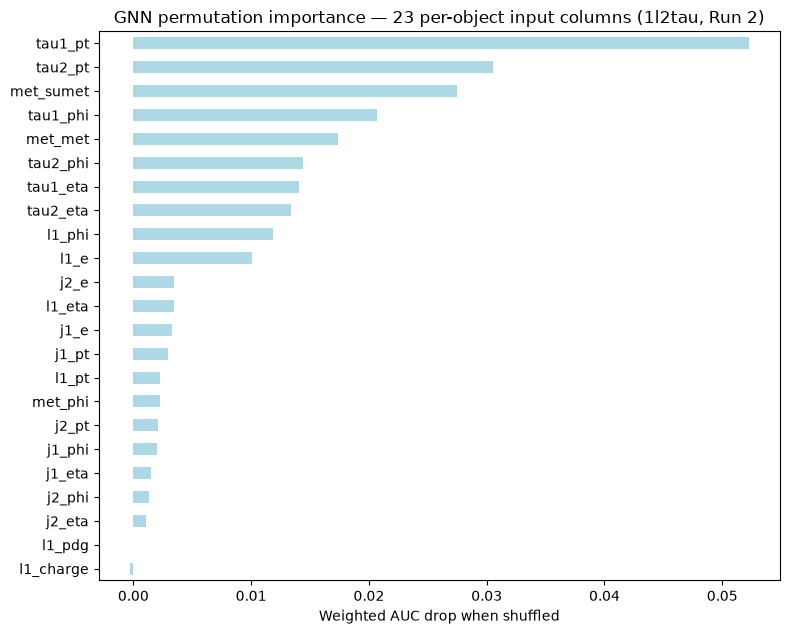

tau1_pt      0.052272
tau2_pt      0.030530
met_sumet    0.027470
tau1_phi     0.020726
met_met      0.017333
tau2_phi     0.014364
tau1_eta     0.014023
tau2_eta     0.013410
l1_phi       0.011879
l1_e         0.010036
j2_e         0.003451
l1_eta       0.003412
j1_e         0.003297
j1_pt        0.002939
l1_pt        0.002259
met_phi      0.002239
j2_pt        0.002079
j1_phi       0.001969
j1_eta       0.001469
j2_phi       0.001358
j2_eta       0.001096
l1_pdg      -0.000019
l1_charge   -0.000312
Name: auc_drop, dtype: float64

In [65]:
importance = permutation_importance_gnn(
    model, val_scaled, val_imp, y_val, w_val, REQUIRED_OBJECT_COLUMNS, n_repeats=5,
)
plot_importance_bar(
    importance, top_n=30,
    title=f"GNN permutation importance — {len(REQUIRED_OBJECT_COLUMNS)} per-object input columns (1l2tau, Run 2)",
)
importance

## Physics Figure of Merit & Held-Out Test Evaluation

Weighted AUC is a global ranking metric; for HH what matters is significance
in the high-score region - same max-Asimov-significance scan as
`DNN.ipynb`. The score cut is selected by scanning **VAL** only, then applied
**frozen** to the never-before-seen **TEST** partition, scored exactly once.

In [66]:
def significance_scan(y_true, scores, w_phys, n_thr=200, min_bkg=1.0):

    """
    Max Asimov significance over score cuts. Uses SIGNED w_phys (expected
    yields, not |w_phys|). `min_bkg` guards the sparse high-score tail
    where Z is unstable when B is tiny or negative. Treat Z as a RELATIVE
    metric for ranking models on identical rows, not an absolute discovery
    number (it depends on sample normalization/luminosity).
    """

    thr = np.quantile(scores, np.linspace(0, 1, n_thr))
    best_z, best_t = 0.0, None

    for t in thr:
        sel = scores >= t
        S = w_phys[sel & (y_true == 1)].sum()
        B = w_phys[sel & (y_true == 0)].sum()
        if S <= 0 or B < min_bkg:
            continue
        z = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S))
        if z > best_z:
            best_z, best_t = z, t

    return best_z, best_t


w_val_signed = val_df["w_phys"].to_numpy()
z_val, thr_val = significance_scan(y_val, y_val_scores, w_val_signed)

print(f"Weighted val AUC = {auc_val:.4f}")
print(f"Max Asimov Z (val) = {z_val:.3f} at score cut = {thr_val:.4f}")

# ---- HELD-OUT TEST EVALUATION - scored EXACTLY ONCE ------------------------
# X_test/y_test_labels/w_test_abs_t have not participated in anything above
# (not the imputation/scaler fit, not training, not early stopping, not the
# significance-scan cut selection just above). The cut `thr_val` was chosen
# on VAL only; it is applied here FROZEN, NOT re-scanned on test.

test_scores = score_dataset(model, X_test).cpu().numpy()
y_test = y_test_labels.cpu().numpy()
w_test_abs = w_test_abs_t.cpu().numpy()
w_test_signed = test_df["w_phys"].to_numpy()

auc_test = roc_auc_score(y_test, test_scores, sample_weight=w_test_abs)

S_test = w_test_signed[(test_scores >= thr_val) & (y_test == 1)].sum()
B_test = w_test_signed[(test_scores >= thr_val) & (y_test == 0)].sum()
z_test = (np.sqrt(2 * ((S_test + B_test) * np.log(1 + S_test / B_test) - S_test))
          if (S_test > 0 and B_test > 0) else np.nan)

print(f"\nWeighted AUC: val = {auc_val:.4f}  |  test (held-out, scored once) = {auc_test:.4f}")
print(f"At the VAL-selected score cut = {thr_val:.4f} (frozen, NOT re-scanned on test):")
print(f"  test S = {S_test:.2f} | test B = {B_test:.2f} | test Z = {z_test:.3f}  (val Z was {z_val:.3f})")

Weighted val AUC = 0.9100
Max Asimov Z (val) = 0.015 at score cut = 0.8700

Weighted AUC: val = 0.9100  |  test (held-out, scored once) = 0.9166
At the VAL-selected score cut = 0.8700 (frozen, NOT re-scanned on test):
  test S = 0.08 | test B = 24.87 | test Z = 0.015  (val Z was 0.015)


## Sanity Checks & Summary

In [67]:
# ---- Determinism check (same acceptance criterion as DNN.ipynb): re-seeding
# immediately before each of two short training runs should give an EXACT
# match, proving set_seed()/use_deterministic_algorithms(True) pin every
# source of randomness. Cheap config (small model, 5 epochs) purely to keep
# this check fast - not meant to reflect final model quality.

set_seed(RANDOM_STATE)
_, _, det_check_a, _, _ = train_model(hidden_channels=16, n_epochs=5, patience=5, verbose=False)

set_seed(RANDOM_STATE)
_, _, det_check_b, _, _ = train_model(hidden_channels=16, n_epochs=5, patience=5, verbose=False)
assert det_check_a == det_check_b, f"Determinism check FAILED: {det_check_a} != {det_check_b}"

print(f"Determinism check passed: two re-seeded runs give identical val_auc = {det_check_a:.6f}")

# ---- Final summary ----------------------------------------------------------

summary = pd.DataFrame([{
    "model": f"GNN (object nodes, {N_NODES} nodes/event)",
    "val_auc": auc_val,
    "max_asimov_Z (val)": z_val,
    "test_auc (held-out, scored once)": auc_test,
    "test_Z_at_val_cut (held-out)": z_test,
}])

print("\nFinal summary (GNN, 1l2tau Run 2):")
print(summary.to_string(index=False))
summary

/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/es

Determinism check passed: two re-seeded runs give identical val_auc = 0.876155

Final summary (GNN, 1l2tau Run 2):
                            model  val_auc  max_asimov_Z (val)  test_auc (held-out, scored once)  test_Z_at_val_cut (held-out)
GNN (object nodes, 6 nodes/event) 0.909983            0.015083                          0.916594                       0.01524


,model,val_auc,max_asimov_Z (val),"test_auc (held-out, scored once)",test_Z_at_val_cut (held-out)
0,"GNN (object nodes, 6 nodes/event)",0.909983,0.015083,0.916594,0.01524


## Run 3 (Separate Downstream Section)

Identical procedure to the Run 2 section above, independently on **Run 3**
only (own `data_run3`/`features_run3`, own train/val/test split, own median/
scaler fit, own trained model) — mirrors `DNN.ipynb`'s "Run 3 (Separate
Downstream Section)". Every variable below is `_run3`-suffixed so the Run 2
results above are untouched; the shared helper functions (`make_3way_split`,
`build_graph_tensors`, `train_model`, `permutation_importance_gnn`, ...) and
the global Object/Node schema (`OBJECT_COLUMNS`, `EDGE_INDEX`, ...) defined
in the Run 2 section are reused as-is — the graph representation is fixed
(same 6 nodes/event, same 11 features/node) regardless of which campaign
feeds it.


In [68]:
# Activate Run 3 as the downstream dataset. Everything below uses `_run3`
# suffixed variable names so the Run 2 results above remain untouched.

candidate_features, data, features = candidate_features_run3, data_run3, features_run3
BASE_DIR = BASE_DIR_RUN3
ACTIVE_RUN = "Run 3"

missing_run3 = [c for c in REQUIRED_OBJECT_COLUMNS if c not in features]
assert not missing_run3, f"Node schema references columns dropped by clean_data / the leakage policy (Run 3): {missing_run3}"

print(f"Switched downstream dataset to: {ACTIVE_RUN}")
print(f"Events={len(data)} | features={len(features)}")


Switched downstream dataset to: Run 3
Events=1324892 | features=64


## Sentinel Audit (-1) — Run 3

Same diagnostic as the Run 2 section, applied to `data_run3`/`features_run3`.


In [69]:
NEG1_SENTINEL_FEATURES_run3 = set()

neg1_rows_run3 = []
for f in features_run3:
    vals = data_run3[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows_run3.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df_run3 = pd.DataFrame(neg1_rows_run3).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df_run3)} / {len(features_run3)} features have at least one row exactly equal to -1:")
print(neg1_df_run3.to_string(index=False))

for f in NEG1_SENTINEL_FEATURES_run3:
    data_run3[f] = data_run3[f].mask(data_run3[f] == -1)

if NEG1_SENTINEL_FEATURES_run3:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES_run3)}")
else:
    print("\nNEG1_SENTINEL_FEATURES_run3 is empty - no -1 values masked.")


1 / 64 features have at least one row exactly equal to -1:
  feature  frac_exactly_-1  gap_to_next_value_above
l1_charge         0.474795                      2.0

NEG1_SENTINEL_FEATURES_run3 is empty - no -1 values masked.


## Train/Validation/Test Split — Run 3

Same deterministic **80/10/10** `make_3way_split`, median imputation and
`StandardScaler` fit (train only) as the Run 2 section, applied to
`data_run3`. Reuses the global `REQUIRED_OBJECT_COLUMNS`/`CONTINUOUS_NODE_COLS`
schema unchanged — the node representation doesn't depend on which campaign
the raw branches come from.


In [70]:
train_df_run3, val_df_run3, test_df_run3 = make_3way_split(data_run3)

SPLIT_DIR_RUN3 = BASE_DIR_RUN3 / "splits"
assert_same_test_partition(test_df_run3, SPLIT_DIR_RUN3 / "test.root")

train_medians_run3 = train_df_run3[REQUIRED_OBJECT_COLUMNS].median()

train_imp_run3 = train_df_run3[REQUIRED_OBJECT_COLUMNS].fillna(train_medians_run3)
val_imp_run3 = val_df_run3[REQUIRED_OBJECT_COLUMNS].fillna(train_medians_run3)
test_imp_run3 = test_df_run3[REQUIRED_OBJECT_COLUMNS].fillna(train_medians_run3)

scaler_run3 = StandardScaler()
train_scaled_run3 = train_imp_run3.copy()
val_scaled_run3 = val_imp_run3.copy()
test_scaled_run3 = test_imp_run3.copy()
train_scaled_run3[CONTINUOUS_NODE_COLS] = scaler_run3.fit_transform(train_imp_run3[CONTINUOUS_NODE_COLS])
val_scaled_run3[CONTINUOUS_NODE_COLS] = scaler_run3.transform(val_imp_run3[CONTINUOUS_NODE_COLS])
test_scaled_run3[CONTINUOUS_NODE_COLS] = scaler_run3.transform(test_imp_run3[CONTINUOUS_NODE_COLS])

assert np.isfinite(train_scaled_run3.to_numpy()).all(), "NaN/inf reached the model input (train, Run 3)"
assert np.isfinite(val_scaled_run3.to_numpy()).all(), "NaN/inf reached the model input (val, Run 3)"
assert np.isfinite(test_scaled_run3.to_numpy()).all(), "NaN/inf reached the model input (test, Run 3)"

print("Imputation + scaling done (fit on Run 3 train only).")


Train:  1059912 events | signal =  164040 (yield=      1.67) | background =  895872 (yield=  15588.90) | signal weight scale factor = 9358.6
Val  :   132490 events | signal =   20505 (yield=      0.21) | background =  111985 (yield=   1910.84) | signal weight scale factor = 9270.7
Test :   132490 events | signal =   20505 (yield=      0.21) | background =  111985 (yield=   1867.19) | signal weight scale factor = 8929.3
  cross-check OK: PPSSP_2026/1l2tau/run3/splits/test.root test partition matches on 69 shared columns (132490 rows)
Imputation + scaling done (fit on Run 3 train only).


## Graph Construction — Run 3

Reuses `stack_node_features`/`build_graph_tensors` from the Run 2 section,
applied to the Run 3 splits.


In [71]:
w_train_fit_run3 = make_fit_weights(train_df_run3["label"].to_numpy(), np.abs(train_df_run3["w_phys"].to_numpy()))

X_train_run3, y_train_run3, w_train_fit_t_run3, w_train_eval_t_run3 = build_graph_tensors(
    train_scaled_run3, train_imp_run3, train_df_run3, fit_weights=w_train_fit_run3
)
X_val_run3, y_val_labels_run3, _, w_val_abs_run3 = build_graph_tensors(val_scaled_run3, val_imp_run3, val_df_run3)
X_test_run3, y_test_labels_run3, _, w_test_abs_t_run3 = build_graph_tensors(test_scaled_run3, test_imp_run3, test_df_run3)

print(f"Built {X_train_run3.shape[0]} train / {X_val_run3.shape[0]} val / {X_test_run3.shape[0]} test graphs (Run 3, GPU-resident tensors)")


Built 1059912 train / 132490 val / 132490 test graphs (Run 3, GPU-resident tensors)


## Training Loop — Run 3

Reuses the same `train_model`/`run_epoch` functions defined in the Run 2
section above, with explicit `_run3` tensors passed in so the Run 2 model/
history are untouched.


In [72]:
model_run3, history_run3, best_val_auc_run3, best_train_auc_run3, best_train_auc_eval_run3 = train_model(
    X_train_data=X_train_run3, y_train_data=y_train_run3,
    w_train_fit_data=w_train_fit_t_run3, w_train_eval_data=w_train_eval_t_run3,
    X_val_data=X_val_run3, y_val_data=y_val_labels_run3, w_val_data=w_val_abs_run3,
)

print(f"\nBest val_auc = {best_val_auc_run3:.4f} | train_auc (dropout on) = {best_train_auc_run3:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval_run3:.4f}")


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch   1 | train_loss=0.5224 val_loss=0.3671 | train_auc=0.8311 train_auc_eval=0.8911 val_auc=0.8949


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch   2 | train_loss=0.4344 val_loss=0.3790 | train_auc=0.8804 train_auc_eval=0.8930 val_auc=0.8962


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


...

Epoch  48 | train_loss=0.3637 val_loss=0.4227 | train_auc=0.9187 train_auc_eval=0.9241 val_auc=0.9207


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch  49 | train_loss=0.3632 val_loss=0.4117 | train_auc=0.9189 train_auc_eval=0.9211 val_auc=0.9191


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch  50 | train_loss=0.3649 val_loss=0.4637 | train_auc=0.9182 train_auc_eval=0.9178 val_auc=0.9160

Best val_auc = 0.9208 | train_auc (dropout on) = 0.9181 | train_auc_eval (dropout off, comparable) = 0.9235


## Evaluation — Run 3


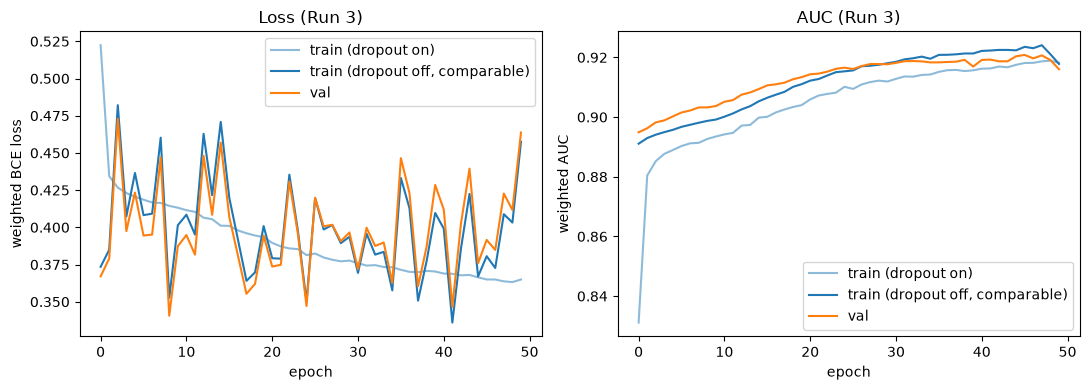

Final weighted val AUC (Run 3) = 0.9208


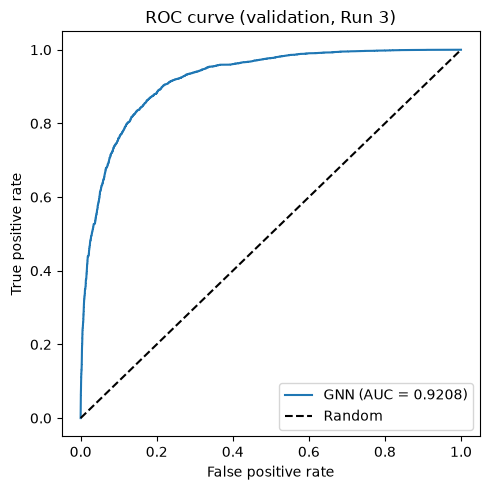

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_run3["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history_run3["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history_run3["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss (Run 3)")
axes[0].legend()

axes[1].plot(history_run3["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history_run3["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history_run3["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC (Run 3)")
axes[1].legend()

plt.tight_layout()
plt.show()

y_val_scores_run3 = score_dataset(model_run3, X_val_run3).cpu().numpy()
y_val_run3 = y_val_labels_run3.cpu().numpy()
w_val_run3 = w_val_abs_run3.cpu().numpy()

auc_val_run3 = roc_auc_score(y_val_run3, y_val_scores_run3, sample_weight=w_val_run3)
print(f"Final weighted val AUC (Run 3) = {auc_val_run3:.4f}")

fpr_run3, tpr_run3, _ = roc_curve(y_val_run3, y_val_scores_run3, sample_weight=w_val_run3)
plt.figure(figsize=(5, 5))
plt.plot(fpr_run3, tpr_run3, label=f"GNN (AUC = {auc_val_run3:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation, Run 3)")
plt.legend()
plt.tight_layout()
plt.show()


## Feature Importance (Permutation) — Run 3

Same technique as the Run 2 section, applied to `model_run3`/`val_scaled_run3`.


Baseline weighted val AUC: 0.9208


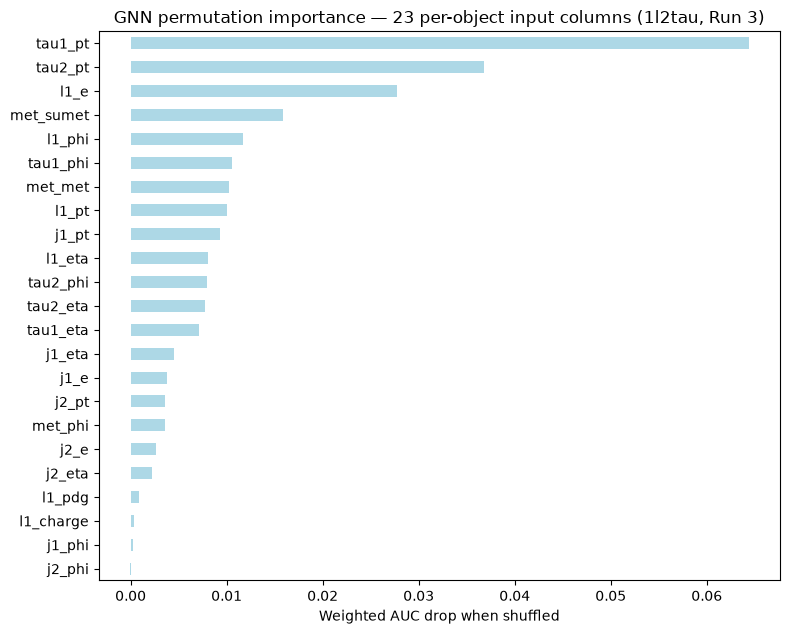

tau1_pt      0.064399
tau2_pt      0.036800
l1_e         0.027785
met_sumet    0.015821
l1_phi       0.011703
tau1_phi     0.010544
met_met      0.010207
l1_pt        0.009994
j1_pt        0.009289
l1_eta       0.008091
tau2_phi     0.007986
tau2_eta     0.007776
tau1_eta     0.007079
j1_eta       0.004468
j1_e         0.003748
j2_pt        0.003555
met_phi      0.003551
j2_e         0.002681
j2_eta       0.002211
l1_pdg       0.000915
l1_charge    0.000370
j1_phi       0.000272
j2_phi      -0.000097
Name: auc_drop, dtype: float64

In [74]:
importance_run3 = permutation_importance_gnn(
    model_run3, val_scaled_run3, val_imp_run3, y_val_run3, w_val_run3, REQUIRED_OBJECT_COLUMNS, n_repeats=5,
)
plot_importance_bar(
    importance_run3, top_n=30,
    title=f"GNN permutation importance — {len(REQUIRED_OBJECT_COLUMNS)} per-object input columns (1l2tau, Run 3)",
)
importance_run3


## Physics Figure of Merit & Held-Out Test Evaluation — Run 3

Same max-Asimov-significance scan as the Run 2 section: the score cut is
selected by scanning **VAL** only, then applied **frozen** to the
never-before-seen Run 3 **TEST** partition, scored exactly once.


In [75]:
w_val_signed_run3 = val_df_run3["w_phys"].to_numpy()
z_val_run3, thr_val_run3 = significance_scan(y_val_run3, y_val_scores_run3, w_val_signed_run3)

print(f"Weighted val AUC (Run 3) = {auc_val_run3:.4f}")
print(f"Max Asimov Z (val, Run 3) = {z_val_run3:.3f} at score cut = {thr_val_run3:.4f}")

# ---- HELD-OUT TEST EVALUATION (Run 3) - scored EXACTLY ONCE ----------------

test_scores_run3 = score_dataset(model_run3, X_test_run3).cpu().numpy()
y_test_run3 = y_test_labels_run3.cpu().numpy()
w_test_abs_run3 = w_test_abs_t_run3.cpu().numpy()
w_test_signed_run3 = test_df_run3["w_phys"].to_numpy()

auc_test_run3 = roc_auc_score(y_test_run3, test_scores_run3, sample_weight=w_test_abs_run3)

S_test_run3 = w_test_signed_run3[(test_scores_run3 >= thr_val_run3) & (y_test_run3 == 1)].sum()
B_test_run3 = w_test_signed_run3[(test_scores_run3 >= thr_val_run3) & (y_test_run3 == 0)].sum()
z_test_run3 = (np.sqrt(2 * ((S_test_run3 + B_test_run3) * np.log(1 + S_test_run3 / B_test_run3) - S_test_run3))
               if (S_test_run3 > 0 and B_test_run3 > 0) else np.nan)

print(f"\nWeighted AUC: val = {auc_val_run3:.4f}  |  test (held-out, scored once) = {auc_test_run3:.4f}")
print(f"At the VAL-selected score cut = {thr_val_run3:.4f} (frozen, NOT re-scanned on test):")
print(f"  test S = {S_test_run3:.2f} | test B = {B_test_run3:.2f} | test Z = {z_test_run3:.3f}  (val Z was {z_val_run3:.3f})")


Weighted val AUC (Run 3) = 0.9208
Max Asimov Z (val, Run 3) = 0.015 at score cut = 0.9163

Weighted AUC: val = 0.9208  |  test (held-out, scored once) = 0.9200
At the VAL-selected score cut = 0.9163 (frozen, NOT re-scanned on test):
  test S = 0.08 | test B = 34.40 | test Z = 0.013  (val Z was 0.015)


## Sanity Checks & Summary — Run 3


In [76]:
# ---- Determinism check (Run 3) - re-seeding immediately before each of two
# short training runs on the Run 3 tensors should give an EXACT match.

set_seed(RANDOM_STATE)
_, _, det_check_a_run3, _, _ = train_model(
    hidden_channels=16, n_epochs=5, patience=5, verbose=False,
    X_train_data=X_train_run3, y_train_data=y_train_run3,
    w_train_fit_data=w_train_fit_t_run3, w_train_eval_data=w_train_eval_t_run3,
    X_val_data=X_val_run3, y_val_data=y_val_labels_run3, w_val_data=w_val_abs_run3,
)

set_seed(RANDOM_STATE)
_, _, det_check_b_run3, _, _ = train_model(
    hidden_channels=16, n_epochs=5, patience=5, verbose=False,
    X_train_data=X_train_run3, y_train_data=y_train_run3,
    w_train_fit_data=w_train_fit_t_run3, w_train_eval_data=w_train_eval_t_run3,
    X_val_data=X_val_run3, y_val_data=y_val_labels_run3, w_val_data=w_val_abs_run3,
)
assert det_check_a_run3 == det_check_b_run3, f"Determinism check FAILED (Run 3): {det_check_a_run3} != {det_check_b_run3}"

print(f"Determinism check passed (Run 3): two re-seeded runs give identical val_auc = {det_check_a_run3:.6f}")

# ---- Final summary (Run 3) --------------------------------------------------

summary_run3 = pd.DataFrame([{
    "model": f"GNN (object nodes, {N_NODES} nodes/event)",
    "val_auc": auc_val_run3,
    "max_asimov_Z (val)": z_val_run3,
    "test_auc (held-out, scored once)": auc_test_run3,
    "test_Z_at_val_cut (held-out)": z_test_run3,
}])

print("\nFinal summary (GNN, 1l2tau Run 3):")
print(summary_run3.to_string(index=False))
summary_run3


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/es

Determinism check passed (Run 3): two re-seeded runs give identical val_auc = 0.898526

Final summary (GNN, 1l2tau Run 3):
                            model  val_auc  max_asimov_Z (val)  test_auc (held-out, scored once)  test_Z_at_val_cut (held-out)
GNN (object nodes, 6 nodes/event) 0.920826            0.015473                          0.920033                      0.012872


,model,val_auc,max_asimov_Z (val),"test_auc (held-out, scored once)",test_Z_at_val_cut (held-out)
0,"GNN (object nodes, 6 nodes/event)",0.920826,0.015473,0.920033,0.012872


## Run 2 + Run 3 — Combined Track

Concatenates Run 2 and Run 3 events (features restricted to those common to
both campaigns) into one training sample and reruns the same pipeline —
mirrors `DNN.ipynb`'s Combined section. An extra `run` bookkeeping column
(2 or 3) is kept (never fed to the model — it isn't part of
`REQUIRED_OBJECT_COLUMNS`) so `make_3way_split` can stratify on `label` AND
`run` jointly.


In [77]:
# Combined uses features common to BOTH runs (equivalent to discovering
# common branches across all process files in both directories).

candidate_features_comb = sorted(set(features_run2) & set(features_run3))

keep_cols_comb = candidate_features_comb + ["w_phys", "label", "process"]

data_run2_tagged = data_run2[keep_cols_comb].copy()
data_run2_tagged["run"] = 2

data_run3_tagged = data_run3[keep_cols_comb].copy()
data_run3_tagged["run"] = 3

data_comb_raw = pd.concat([data_run2_tagged, data_run3_tagged], ignore_index=True)
data_comb, features_comb = clean_data(data_comb_raw, candidate_features_comb)

candidate_features, data, features = candidate_features_comb, data_comb, features_comb
BASE_DIR = BASE_DIR_COMB
ACTIVE_RUN = "Combined"

missing_comb = [c for c in REQUIRED_OBJECT_COLUMNS if c not in features]
assert not missing_comb, f"Node schema references columns dropped by clean_data / the leakage policy (Combined): {missing_comb}"

print(f"\nCombined: {len(data_comb)} events, {len(features_comb)} features "
      f"(intersection of Run2's {len(features_run2)} and Run3's {len(features_run3)})")

for run_label in (2, 3):
    sub = data_comb[data_comb["run"] == run_label]
    print(f"Run {run_label}: signal yield = {sub.loc[sub.label==1,'w_phys'].sum():.2f} | "
          f"background yield = {sub.loc[sub.label==0,'w_phys'].sum():.2f} | n_events = {len(sub)}")


Dropped 0 constant/empty features:
  []

64 final features
Total: 2015576 events | signal = 293764 | background = 1721812
Yield (w_phys): signal = 3.91 | background = 30834.21

Combined: 2015576 events, 64 features (intersection of Run2's 64 and Run3's 64)
Run 2: signal yield = 1.82 | background yield = 11467.29 | n_events = 690684
Run 3: signal yield = 2.08 | background yield = 19366.92 | n_events = 1324892


## Sentinel Audit (-1) — Combined

Same diagnostic, applied to `data_comb`/`features_comb`.


In [78]:
NEG1_SENTINEL_FEATURES_comb = set()

neg1_rows_comb = []
for f in features_comb:
    vals = data_comb[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows_comb.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df_comb = pd.DataFrame(neg1_rows_comb).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df_comb)} / {len(features_comb)} features have at least one row exactly equal to -1:")
print(neg1_df_comb.to_string(index=False))

for f in NEG1_SENTINEL_FEATURES_comb:
    data_comb[f] = data_comb[f].mask(data_comb[f] == -1)

if NEG1_SENTINEL_FEATURES_comb:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES_comb)}")
else:
    print("\nNEG1_SENTINEL_FEATURES_comb is empty - no -1 values masked.")


1 / 64 features have at least one row exactly equal to -1:
  feature  frac_exactly_-1  gap_to_next_value_above
l1_charge         0.474537                      2.0

NEG1_SENTINEL_FEATURES_comb is empty - no -1 values masked.


## Train/Validation/Test Split — Combined

Same `make_3way_split`, now stratified on `label` AND `run` jointly
(`extra_stratify_col="run"`) so the Run2/Run3 mix in train/val/test is
balanced, plus median imputation and `StandardScaler` fit (train only).


In [79]:
train_df_comb, val_df_comb, test_df_comb = make_3way_split(data_comb, extra_stratify_col="run")

SPLIT_DIR_COMB = BASE_DIR_COMB / "splits"
assert_same_test_partition(test_df_comb, SPLIT_DIR_COMB / "test.root")

train_medians_comb = train_df_comb[REQUIRED_OBJECT_COLUMNS].median()

train_imp_comb = train_df_comb[REQUIRED_OBJECT_COLUMNS].fillna(train_medians_comb)
val_imp_comb = val_df_comb[REQUIRED_OBJECT_COLUMNS].fillna(train_medians_comb)
test_imp_comb = test_df_comb[REQUIRED_OBJECT_COLUMNS].fillna(train_medians_comb)

scaler_comb = StandardScaler()
train_scaled_comb = train_imp_comb.copy()
val_scaled_comb = val_imp_comb.copy()
test_scaled_comb = test_imp_comb.copy()
train_scaled_comb[CONTINUOUS_NODE_COLS] = scaler_comb.fit_transform(train_imp_comb[CONTINUOUS_NODE_COLS])
val_scaled_comb[CONTINUOUS_NODE_COLS] = scaler_comb.transform(val_imp_comb[CONTINUOUS_NODE_COLS])
test_scaled_comb[CONTINUOUS_NODE_COLS] = scaler_comb.transform(test_imp_comb[CONTINUOUS_NODE_COLS])

assert np.isfinite(train_scaled_comb.to_numpy()).all(), "NaN/inf reached the model input (train, Combined)"
assert np.isfinite(val_scaled_comb.to_numpy()).all(), "NaN/inf reached the model input (val, Combined)"
assert np.isfinite(test_scaled_comb.to_numpy()).all(), "NaN/inf reached the model input (test, Combined)"

print("Imputation + scaling done (fit on Combined train only).")


Train:  1612460 events | signal =  235011 (yield=      3.13) | background = 1377449 (yield=  24677.47) | signal weight scale factor = 7886.8
Val  :   201558 events | signal =   29377 (yield=      0.39) | background =  172181 (yield=   3213.90) | signal weight scale factor = 8315.5
Test :   201558 events | signal =   29376 (yield=      0.39) | background =  172182 (yield=   2942.84) | signal weight scale factor = 7548.5
  cross-check OK: PPSSP_2026/1l2tau/combined/splits/test.root test partition matches on 67 shared columns (201558 rows)
Imputation + scaling done (fit on Combined train only).


## Graph Construction — Combined


In [80]:
w_train_fit_comb = make_fit_weights(train_df_comb["label"].to_numpy(), np.abs(train_df_comb["w_phys"].to_numpy()))

X_train_comb, y_train_comb, w_train_fit_t_comb, w_train_eval_t_comb = build_graph_tensors(
    train_scaled_comb, train_imp_comb, train_df_comb, fit_weights=w_train_fit_comb
)
X_val_comb, y_val_labels_comb, _, w_val_abs_comb = build_graph_tensors(val_scaled_comb, val_imp_comb, val_df_comb)
X_test_comb, y_test_labels_comb, _, w_test_abs_t_comb = build_graph_tensors(test_scaled_comb, test_imp_comb, test_df_comb)

print(f"Built {X_train_comb.shape[0]} train / {X_val_comb.shape[0]} val / {X_test_comb.shape[0]} test graphs (Combined, GPU-resident tensors)")


Built 1612460 train / 201558 val / 201558 test graphs (Combined, GPU-resident tensors)


## Training Loop — Combined

Reuses the same `train_model`/`run_epoch` functions, with explicit `_comb`
tensors so the Run 2/Run 3 models above are untouched.


In [81]:
model_comb, history_comb, best_val_auc_comb, best_train_auc_comb, best_train_auc_eval_comb = train_model(
    X_train_data=X_train_comb, y_train_data=y_train_comb,
    w_train_fit_data=w_train_fit_t_comb, w_train_eval_data=w_train_eval_t_comb,
    X_val_data=X_val_comb, y_val_data=y_val_labels_comb, w_val_data=w_val_abs_comb,
)

print(f"\nBest val_auc = {best_val_auc_comb:.4f} | train_auc (dropout on) = {best_train_auc_comb:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval_comb:.4f}")


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch   1 | train_loss=0.4938 val_loss=0.4022 | train_auc=0.8458 train_auc_eval=0.8874 val_auc=0.8879


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch   2 | train_loss=0.4335 val_loss=0.4974 | train_auc=0.8811 train_auc_eval=0.8891 val_auc=0.8898


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


...

Epoch  48 | train_loss=0.3611 val_loss=0.3813 | train_auc=0.9199 train_auc_eval=0.9252 val_auc=0.9222


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch  49 | train_loss=0.3607 val_loss=0.4025 | train_auc=0.9200 train_auc_eval=0.9252 val_auc=0.9227


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch  50 | train_loss=0.3612 val_loss=0.3983 | train_auc=0.9198 train_auc_eval=0.9256 val_auc=0.9226

Best val_auc = 0.9227 | train_auc (dropout on) = 0.9200 | train_auc_eval (dropout off, comparable) = 0.9252


## Evaluation — Combined


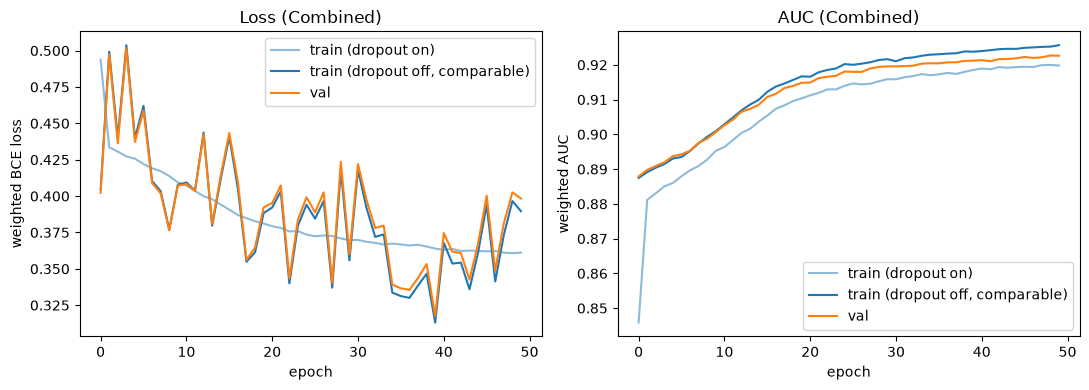

Final weighted val AUC (Combined) = 0.9227


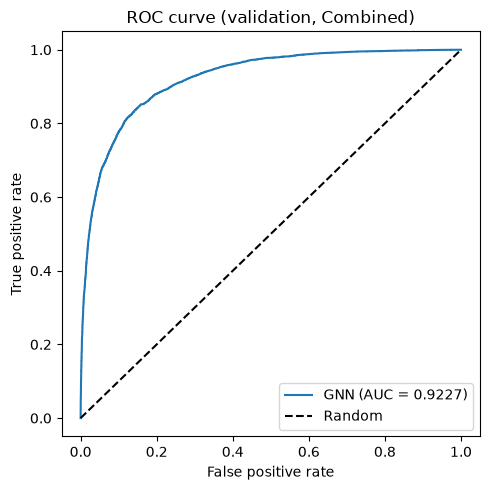

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_comb["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history_comb["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history_comb["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss (Combined)")
axes[0].legend()

axes[1].plot(history_comb["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history_comb["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history_comb["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC (Combined)")
axes[1].legend()

plt.tight_layout()
plt.show()

y_val_scores_comb = score_dataset(model_comb, X_val_comb).cpu().numpy()
y_val_comb = y_val_labels_comb.cpu().numpy()
w_val_comb = w_val_abs_comb.cpu().numpy()

auc_val_comb = roc_auc_score(y_val_comb, y_val_scores_comb, sample_weight=w_val_comb)
print(f"Final weighted val AUC (Combined) = {auc_val_comb:.4f}")

fpr_comb, tpr_comb, _ = roc_curve(y_val_comb, y_val_scores_comb, sample_weight=w_val_comb)
plt.figure(figsize=(5, 5))
plt.plot(fpr_comb, tpr_comb, label=f"GNN (AUC = {auc_val_comb:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation, Combined)")
plt.legend()
plt.tight_layout()
plt.show()


## Feature Importance (Permutation) — Combined


Baseline weighted val AUC: 0.9227


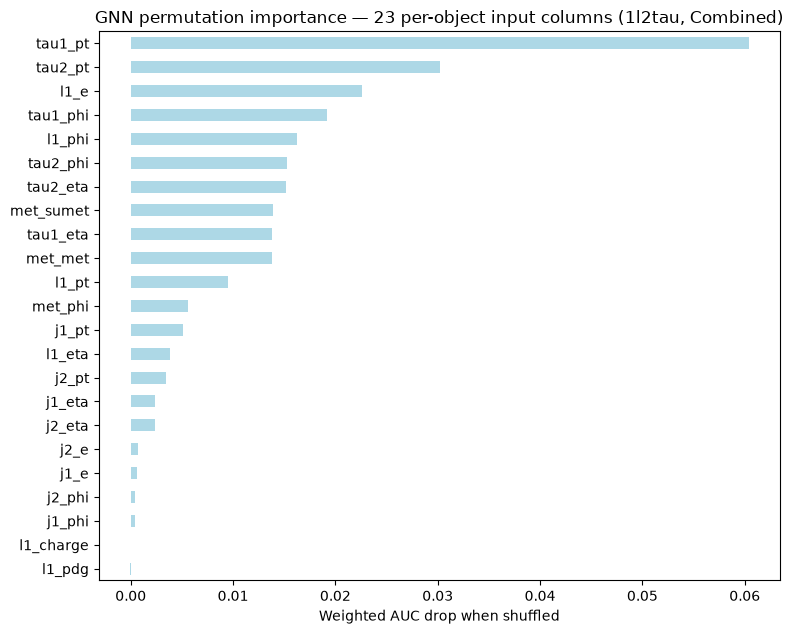

tau1_pt      0.060418
tau2_pt      0.030176
l1_e         0.022601
tau1_phi     0.019177
l1_phi       0.016274
tau2_phi     0.015233
tau2_eta     0.015197
met_sumet    0.013945
tau1_eta     0.013819
met_met      0.013767
l1_pt        0.009490
met_phi      0.005563
j1_pt        0.005091
l1_eta       0.003880
j2_pt        0.003431
j1_eta       0.002384
j2_eta       0.002345
j2_e         0.000735
j1_e         0.000607
j2_phi       0.000451
j1_phi       0.000447
l1_charge    0.000014
l1_pdg      -0.000100
Name: auc_drop, dtype: float64

In [83]:
importance_comb = permutation_importance_gnn(
    model_comb, val_scaled_comb, val_imp_comb, y_val_comb, w_val_comb, REQUIRED_OBJECT_COLUMNS, n_repeats=5,
)
plot_importance_bar(
    importance_comb, top_n=30,
    title=f"GNN permutation importance — {len(REQUIRED_OBJECT_COLUMNS)} per-object input columns (1l2tau, Combined)",
)
importance_comb


## Physics Figure of Merit & Held-Out Test Evaluation — Combined

Same max-Asimov-significance scan: the score cut is selected by scanning
**VAL** only, then applied **frozen** to the never-before-seen Combined
**TEST** partition, scored exactly once.


In [84]:
w_val_signed_comb = val_df_comb["w_phys"].to_numpy()
z_val_comb, thr_val_comb = significance_scan(y_val_comb, y_val_scores_comb, w_val_signed_comb)

print(f"Weighted val AUC (Combined) = {auc_val_comb:.4f}")
print(f"Max Asimov Z (val, Combined) = {z_val_comb:.3f} at score cut = {thr_val_comb:.4f}")

# ---- HELD-OUT TEST EVALUATION (Combined) - scored EXACTLY ONCE -------------

test_scores_comb = score_dataset(model_comb, X_test_comb).cpu().numpy()
y_test_comb = y_test_labels_comb.cpu().numpy()
w_test_abs_comb = w_test_abs_t_comb.cpu().numpy()
w_test_signed_comb = test_df_comb["w_phys"].to_numpy()

auc_test_comb = roc_auc_score(y_test_comb, test_scores_comb, sample_weight=w_test_abs_comb)

S_test_comb = w_test_signed_comb[(test_scores_comb >= thr_val_comb) & (y_test_comb == 1)].sum()
B_test_comb = w_test_signed_comb[(test_scores_comb >= thr_val_comb) & (y_test_comb == 0)].sum()
z_test_comb = (np.sqrt(2 * ((S_test_comb + B_test_comb) * np.log(1 + S_test_comb / B_test_comb) - S_test_comb))
               if (S_test_comb > 0 and B_test_comb > 0) else np.nan)

print(f"\nWeighted AUC: val = {auc_val_comb:.4f}  |  test (held-out, scored once) = {auc_test_comb:.4f}")
print(f"At the VAL-selected score cut = {thr_val_comb:.4f} (frozen, NOT re-scanned on test):")
print(f"  test S = {S_test_comb:.2f} | test B = {B_test_comb:.2f} | test Z = {z_test_comb:.3f}  (val Z was {z_val_comb:.3f})")


Weighted val AUC (Combined) = 0.9227
Max Asimov Z (val, Combined) = 0.024 at score cut = 0.9680

Weighted AUC: val = 0.9227  |  test (held-out, scored once) = 0.9228
At the VAL-selected score cut = 0.9680 (frozen, NOT re-scanned on test):
  test S = 0.03 | test B = 1.88 | test Z = 0.020  (val Z was 0.024)


## Sanity Checks & Summary — Combined


In [85]:
# ---- Determinism check (Combined) ------------------------------------------

set_seed(RANDOM_STATE)
_, _, det_check_a_comb, _, _ = train_model(
    hidden_channels=16, n_epochs=5, patience=5, verbose=False,
    X_train_data=X_train_comb, y_train_data=y_train_comb,
    w_train_fit_data=w_train_fit_t_comb, w_train_eval_data=w_train_eval_t_comb,
    X_val_data=X_val_comb, y_val_data=y_val_labels_comb, w_val_data=w_val_abs_comb,
)

set_seed(RANDOM_STATE)
_, _, det_check_b_comb, _, _ = train_model(
    hidden_channels=16, n_epochs=5, patience=5, verbose=False,
    X_train_data=X_train_comb, y_train_data=y_train_comb,
    w_train_fit_data=w_train_fit_t_comb, w_train_eval_data=w_train_eval_t_comb,
    X_val_data=X_val_comb, y_val_data=y_val_labels_comb, w_val_data=w_val_abs_comb,
)
assert det_check_a_comb == det_check_b_comb, f"Determinism check FAILED (Combined): {det_check_a_comb} != {det_check_b_comb}"

print(f"Determinism check passed (Combined): two re-seeded runs give identical val_auc = {det_check_a_comb:.6f}")

# ---- Final summary (Combined) ------------------------------------------------

summary_comb = pd.DataFrame([{
    "model": f"GNN (object nodes, {N_NODES} nodes/event)",
    "val_auc": auc_val_comb,
    "max_asimov_Z (val)": z_val_comb,
    "test_auc (held-out, scored once)": auc_test_comb,
    "test_Z_at_val_cut (held-out)": z_test_comb,
}])

print("\nFinal summary (GNN, 1l2tau Combined):")
print(summary_comb.to_string(index=False))
summary_comb


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/es

Determinism check passed (Combined): two re-seeded runs give identical val_auc = 0.891673

Final summary (GNN, 1l2tau Combined):
                            model  val_auc  max_asimov_Z (val)  test_auc (held-out, scored once)  test_Z_at_val_cut (held-out)
GNN (object nodes, 6 nodes/event) 0.922685            0.024463                          0.922804                      0.019864


,model,val_auc,max_asimov_Z (val),"test_auc (held-out, scored once)",test_Z_at_val_cut (held-out)
0,"GNN (object nodes, 6 nodes/event)",0.922685,0.024463,0.922804,0.019864


## Consolidated Summary — All Tracks

Side-by-side comparison of the three tracks (Run 2, Run 3, Combined), plus a
standardized CSV export (`model_summary_gnn.csv`) for
`Final_Notebooks/ModelComparison.ipynb` to pick up — one row per track, in
the same format as the MLP/DNN/XGBoost pipelines' exports.


In [86]:
consolidated_summary = pd.concat([
    summary.assign(track="Run 2"),
    summary_run3.assign(track="Run 3"),
    summary_comb.assign(track="Combined"),
], ignore_index=True)[["track", "val_auc", "max_asimov_Z (val)",
                        "test_auc (held-out, scored once)", "test_Z_at_val_cut (held-out)"]]

print("Consolidated GNN summary (1l2tau, all tracks):")
print(consolidated_summary.to_string(index=False))

# ---- Export standardized AUC summary for cross-notebook comparison --------
# Written for ModelComparison.ipynb to load - one row per track, so it can be
# combined with the XGBoost/MLP/DNN notebooks' own exports without needing
# to re-run anything.

model_summary_rows = [
    {"channel": "1l2tau", "model": "gnn", "track": "Run 2",
     "val_auc": auc_val, "test_auc": auc_test},
    {"channel": "1l2tau", "model": "gnn", "track": "Run 3",
     "val_auc": auc_val_run3, "test_auc": auc_test_run3},
    {"channel": "1l2tau", "model": "gnn", "track": "Combined",
     "val_auc": auc_val_comb, "test_auc": auc_test_comb},
]
model_summary_df = pd.DataFrame(model_summary_rows)
PLOTS_DIR_SUMMARY_EXPORT = Path("PPSSP_2026/1l2tau/summary_plots")
PLOTS_DIR_SUMMARY_EXPORT.mkdir(parents=True, exist_ok=True)
model_summary_path = PLOTS_DIR_SUMMARY_EXPORT / "model_summary_gnn.csv"
model_summary_df.to_csv(model_summary_path, index=False)
print(f"Saved model comparison summary -> {model_summary_path}")
model_summary_df


Consolidated GNN summary (1l2tau, all tracks):
   track  val_auc  max_asimov_Z (val)  test_auc (held-out, scored once)  test_Z_at_val_cut (held-out)
   Run 2 0.909983            0.015083                          0.916594                      0.015240
   Run 3 0.920826            0.015473                          0.920033                      0.012872
Combined 0.922685            0.024463                          0.922804                      0.019864
Saved model comparison summary -> PPSSP_2026/1l2tau/summary_plots/model_summary_gnn.csv


,channel,model,track,val_auc,test_auc
0,1l2tau,gnn,Run 2,0.909983,0.916594
1,1l2tau,gnn,Run 3,0.920826,0.920033
2,1l2tau,gnn,Combined,0.922685,0.922804
